# E-Commerce Customer Lifetime Value (CLV) & Segmentation

This notebook mirrors the Python implementation in the project (`preprocessing.py`,
`segmentation.py`, `regression.py`, `utils.py`). It walks through:

1. Dataset loading
2. Exploratory Data Analysis (EDA)
3. Data cleaning
4. Feature engineering
5. Feature selection
6. K-Means clustering (customer segmentation)
7. Linear Regression (CLV prediction)
8. Model evaluation & visualizations

**Dataset:** Customer Personality Analysis (Kaggle) — see `README.md` for source and selection rationale.


In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from preprocessing import (
    full_preprocessing_pipeline, get_regression_train_test_split,
    get_segmentation_features, REGRESSION_FEATURES, SEGMENTATION_FEATURES
)
from segmentation import (
    compute_elbow_curve, compute_silhouette_scores, train_kmeans,
    assign_clusters, cluster_summary
)
from regression import train_linear_regression, evaluate_model
from utils import (
    plot_elbow_curve, plot_silhouette_scores, plot_cluster_scatter,
    plot_cluster_counts, plot_actual_vs_predicted, plot_residuals
)

sns.set_style('whitegrid')
%matplotlib inline


## 1. Dataset Loading

In [2]:
df_raw = pd.read_csv('../dataset/customers.csv')
print('Shape:', df_raw.shape)
df_raw.head()


Shape: (2237, 14)


,Customer_ID,Age,Income,Education,Marital_Status,Kidhome,Teenhome,Total_Orders,Average_Order_Value,Purchase_Frequency,Total_Spent,Days_Since_Last_Purchase,Customer_Tenure,CLV
0,5524,57,58138.0,Graduation,Single,0,0,25,64.68,1.1295,1617,58,664,1616.97
1,2174,60,46344.0,Graduation,Single,1,1,6,4.50,1.5789,27,38,114,27.00
2,4141,49,71613.0,Graduation,Together,0,0,21,36.95,2.0128,776,26,313,775.96
3,6182,30,26646.0,Graduation,Together,1,0,8,6.62,1.7143,53,26,140,52.96
4,5324,33,58293.0,PhD,Married,1,0,19,22.21,3.5185,422,94,162,421.99


## 2. Exploratory Data Analysis (EDA)

Basic statistics, data types, and missing-value inspection before any cleaning.

In [3]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 2237 entries, 0 to 2236
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               2237 non-null   int64  
 1   Age                       2237 non-null   int64  
 2   Income                    2213 non-null   float64
 3   Education                 2237 non-null   str    
 4   Marital_Status            2237 non-null   str    
 5   Kidhome                   2237 non-null   int64  
 6   Teenhome                  2237 non-null   int64  
 7   Total_Orders              2237 non-null   int64  
 8   Average_Order_Value       2233 non-null   float64
 9   Purchase_Frequency        2237 non-null   float64
 10  Total_Spent               2237 non-null   int64  
 11  Days_Since_Last_Purchase  2237 non-null   int64  
 12  Customer_Tenure           2237 non-null   int64  
 13  CLV                       2237 non-null   float64
dtypes: float64(4), int6

In [4]:
df_raw.describe()


,Customer_ID,Age,Income,Kidhome,Teenhome,Total_Orders,Average_Order_Value,Purchase_Frequency,Total_Spent,Days_Since_Last_Purchase,Customer_Tenure,CLV
count,2237.000000,2237.000000,2213.000000,2237.000000,2237.000000,2237.000000,2233.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000
mean,5590.726419,45.098346,52236.581563,0.444345,0.506482,14.870809,33.313233,3.853749,605.743406,49.104604,354.790344,605.733317
std,3245.118591,11.701917,25178.603047,0.538467,0.544593,7.676593,45.015995,19.081292,601.840466,28.956073,202.137961,601.852311
min,0.000000,18.000000,1730.000000,0.000000,0.000000,0.000000,0.530000,0.000000,5.000000,0.000000,1.000000,0.000000
25%,2829.000000,37.000000,35246.000000,0.000000,0.000000,8.000000,9.710000,0.746300,69.000000,24.000000,182.000000,69.000000
50%,5455.000000,44.000000,51373.000000,0.000000,0.000000,15.000000,23.380000,1.288300,396.000000,49.000000,357.000000,396.000000
75%,8427.000000,55.000000,68487.000000,1.000000,1.000000,21.000000,45.350000,2.288100,1045.000000,74.000000,530.000000,1044.950000
max,11191.000000,74.000000,666666.000000,2.000000,2.000000,44.000000,1679.000000,570.000000,2525.000000,99.000000,700.000000,2525.040000


In [5]:
missing = df_raw.isna().sum()
missing[missing > 0]


Income                 24
Average_Order_Value     4
dtype: int64

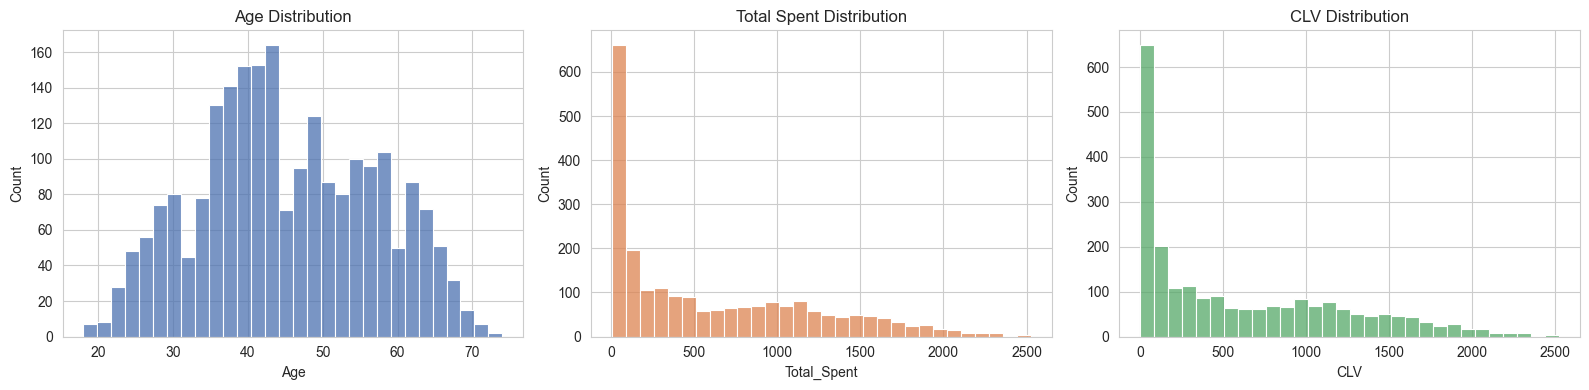

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df_raw['Age'], bins=30, ax=axes[0], color='#4C72B0')
axes[0].set_title('Age Distribution')
sns.histplot(df_raw['Total_Spent'], bins=30, ax=axes[1], color='#DD8452')
axes[1].set_title('Total Spent Distribution')
sns.histplot(df_raw['CLV'], bins=30, ax=axes[2], color='#55A868')
axes[2].set_title('CLV Distribution')
plt.tight_layout()
plt.show()


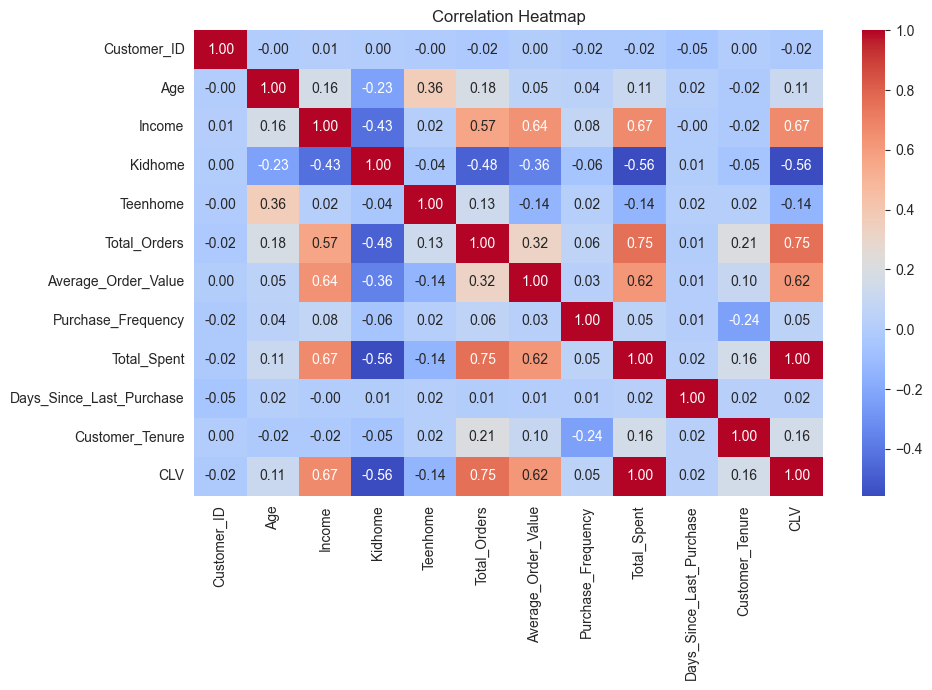

In [7]:
plt.figure(figsize=(10, 7))
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns
sns.heatmap(df_raw[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


## 3. Data Cleaning & Feature Engineering

The raw features (Total_Orders, Total_Spent, Average_Order_Value, Purchase_Frequency,
Days_Since_Last_Purchase, Customer_Tenure, CLV) were already engineered from the original
Kaggle "Customer Personality Analysis" columns when building `dataset/customers.csv`
(see `README.md` for the full derivation). Here we run the reusable cleaning pipeline
from `preprocessing.py`: missing-value imputation, duplicate removal, categorical
encoding, and outlier capping.

In [8]:
pipeline = full_preprocessing_pipeline(path='../dataset/customers.csv')
df = pipeline['clean_df']
summary = pipeline['summary']
summary


{'missing_values_before': {'Income': 24, 'Average_Order_Value': 4},
 'total_missing_values': 28,
 'duplicates_removed': 0,
 'rows_before': 2237,
 'rows_after': 2237,
 'encoded_columns': ['Education', 'Marital_Status'],
 'outlier_capped_columns': ['Purchase_Frequency', 'Average_Order_Value']}

In [9]:
df.head()


,Customer_ID,Age,Income,Education,Marital_Status,Kidhome,Teenhome,Total_Orders,Average_Order_Value,Purchase_Frequency,Total_Spent,Days_Since_Last_Purchase,Customer_Tenure,CLV,Education_Encoded,Marital_Status_Encoded
0,5524,57,58138.0,Graduation,Single,0,0,25,64.68,1.1295,1617,58,664,1616.97,2,4
1,2174,60,46344.0,Graduation,Single,1,1,6,4.50,1.5789,27,38,114,27.00,2,4
2,4141,49,71613.0,Graduation,Together,0,0,21,36.95,2.0128,776,26,313,775.96,2,5
3,6182,30,26646.0,Graduation,Together,1,0,8,6.62,1.7143,53,26,140,52.96,2,5
4,5324,33,58293.0,PhD,Married,1,0,19,22.21,3.5185,422,94,162,421.99,4,3


## 4. Feature Selection

- **Segmentation features:** `Total_Spent`, `Total_Orders`, `Days_Since_Last_Purchase`, `Customer_Tenure`, `Income`
- **Regression features:** `Age`, `Total_Orders`, `Average_Order_Value`, `Purchase_Frequency`, `Days_Since_Last_Purchase`, `Customer_Tenure`
- **Regression target:** `CLV`


## 5. Customer Segmentation — K-Means Clustering

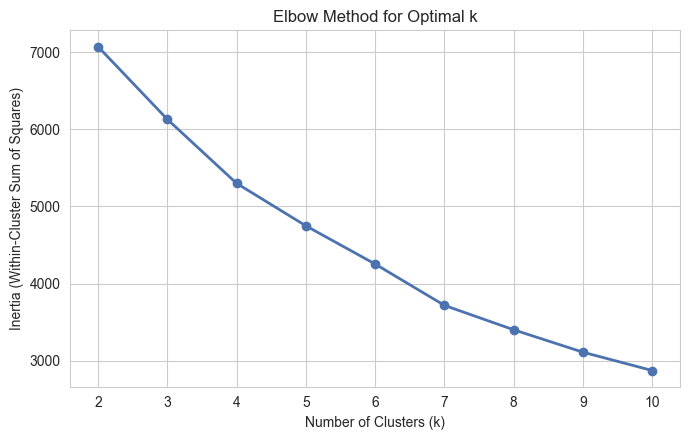

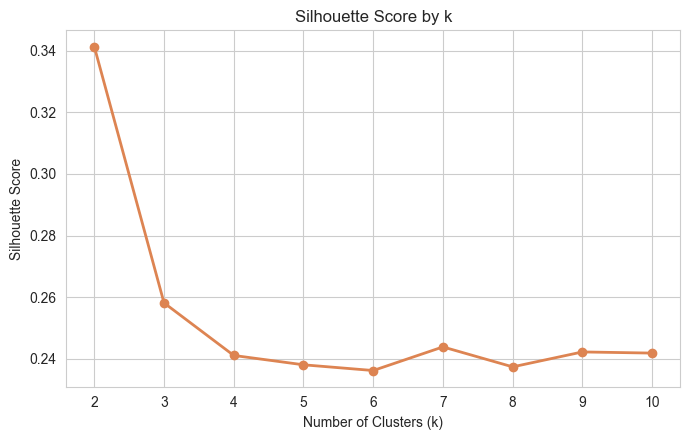

In [10]:
X_raw, X_scaled, seg_scaler = get_segmentation_features(df)
k_values, inertias = compute_elbow_curve(X_scaled, range(2, 11))
_, sil_scores = compute_silhouette_scores(X_scaled, range(2, 11))

fig1 = plot_elbow_curve(k_values, inertias)
fig2 = plot_silhouette_scores(k_values, sil_scores)
plt.show()


In [11]:
best_silhouette_k = k_values[int(np.argmax(sil_scores))]
print('Silhouette-optimal k:', best_silhouette_k)

# k=2 is statistically optimal but produces a trivial split; k=4 is chosen
# for interpretable, actionable business segments.
CHOSEN_K = 4
kmeans_model, labels, sil_score = train_kmeans(X_scaled, n_clusters=CHOSEN_K)
print(f'Chosen k = {CHOSEN_K}, Silhouette Score = {sil_score:.4f}')


Silhouette-optimal k: 2
Chosen k = 4, Silhouette Score = 0.2411


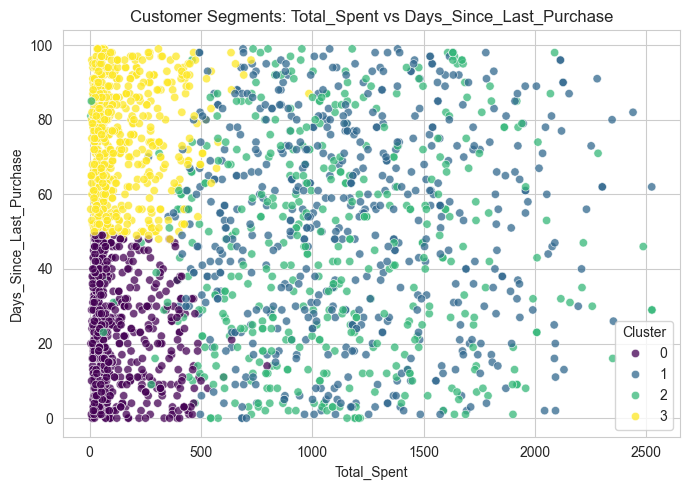

In [12]:
df_clustered = assign_clusters(df, labels)
plot_cluster_scatter(df_clustered, 'Total_Spent', 'Days_Since_Last_Purchase')
plt.show()


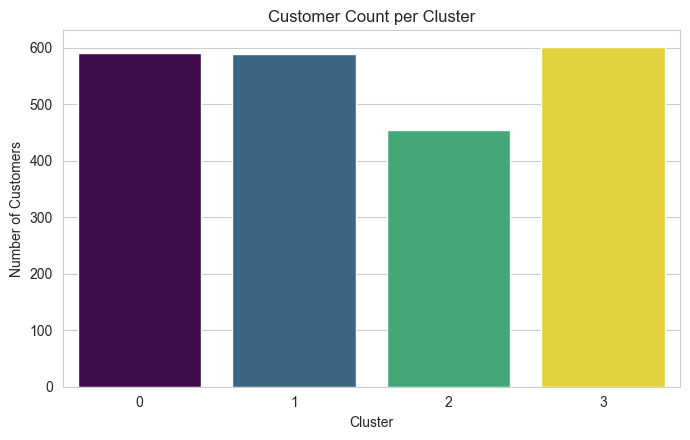

In [13]:
plot_cluster_counts(df_clustered)
plt.show()


In [14]:
cluster_summary(df_clustered, ['Total_Spent','Total_Orders','Days_Since_Last_Purchase','Customer_Tenure','Income'])


,Cluster,Total_Spent,Total_Orders,Days_Since_Last_Purchase,Customer_Tenure,Income,Customer_Count
0,0,132.18,8.86,23.13,326.91,35973.80,591
1,1,1175.46,22.48,52.16,538.31,66824.21,590
2,2,1093.15,20.26,45.25,178.20,74638.59,455
3,3,143.14,9.22,74.57,335.74,36913.72,601


## 6. CLV Prediction — Linear Regression

In [15]:
X_train, X_test, y_train, y_test, reg_scaler = get_regression_train_test_split(df)
reg_model = train_linear_regression(X_train, y_train)
metrics = evaluate_model(reg_model, X_test, y_test)

print(f"RMSE: {metrics['rmse']:.2f}")
print(f"R2 Score: {metrics['r2']:.4f}")
print(f"MAPE: {metrics['mape']:.2f}%")


RMSE: 119.97
R2 Score: 0.9621
MAPE: 91.15%


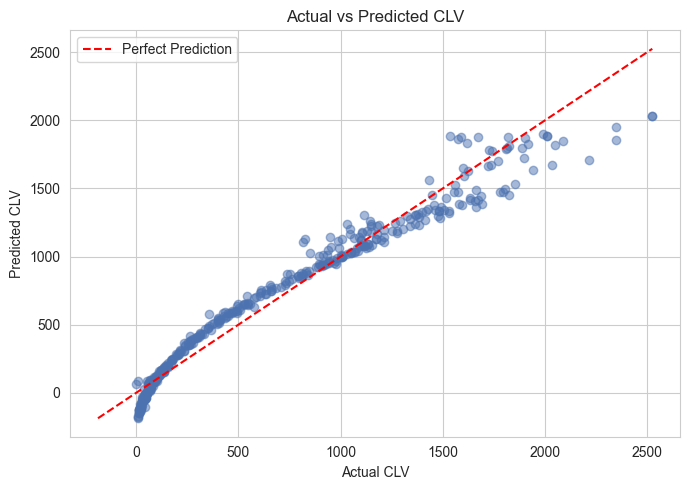

In [16]:
plot_actual_vs_predicted(np.array(metrics['y_test']), metrics['y_pred'])
plt.show()


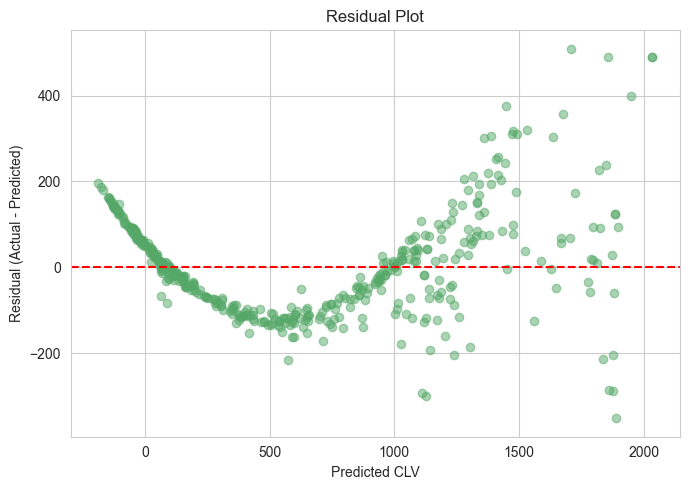

In [17]:
plot_residuals(metrics['y_pred'], np.array(metrics['residuals']))
plt.show()


## 7. Conclusion

- K-Means segmentation (k=4) grouped customers into interpretable segments based on
  spend, order activity, recency, and tenure.
- Linear Regression predicted CLV using Age, Total_Orders, Average_Order_Value,
  Purchase_Frequency, Days_Since_Last_Purchase, and Customer_Tenure, achieving the
  RMSE / R² / MAPE reported above (values are computed live from the dataset — not
  fabricated).
- See `app.py` for the interactive Streamlit dashboard built on top of these models.
